# License

In [ ]:
# ------------------------------------------------------------------------------
#  QuantumThermal sample, written in Python
#
#  Multi-Scale Modeling Laboratory (SMaLL)
#  Website: https://small.polito.it/
#  GitHub repository: https://github.com/SMaLL-PoliTo/QuantumThermal
#
#  Copyright (C) 2025 Pietro Asinari, Matteo Maria Piredda,
#  Giulio Barletta, Paolo De Angelis
#  E-mail contact: pietro.asinari@polito.it
#
#  This code is licensed under the MIT License.
#  You may obtain a copy of the License at
#
#      https://opensource.org/licenses/MIT
#
#  Permission is hereby granted, free of charge, to any person obtaining a copy
#  of this software and associated documentation files (the "Software"), to deal
#  in the Software without restriction, including without limitation the rights
#  to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
#  copies of the Software, and to permit persons to whom the Software is
#  furnished to do so, subject to the following conditions:
#
#  The above copyright notice and this permission notice shall be included in
#  all copies or substantial portions of the Software.
#
#  THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
#  IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
#  FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
#  AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
#  LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
#  OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
#  SOFTWARE.
# ------------------------------------------------------------------------------

# Preparation

In [1]:
# Before running the code, it is necessary to create a conda environment as following:
# conda create -n thermal-science -y python=3.11 ipykernel
#
# Then activate the environment:
# conda activate thermal-science
# 
# Required packages will be installed with the first line of the code
%pip install numpy scipy matplotlib cvxpy pylatexenc
%pip install qiskit==1.4.2 qiskit-aer==0.17.2 qiskit-algorithms==0.3.1
%pip install qrisp==0.7.9

from IPython.display import clear_output
clear_output()

## Preliminaries: finite-difference scheme for heat conduction

In [2]:
import numpy as np
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.linalg import inv, norm

n = 3 # number of qubits, num_qubits
N = pow(2,n) # number of mesh nodes

# T_old
T_old = np.ones(N)
for i in range(N):
    T_old[i] = 1 + (1/2)*np.sin(2*np.pi*(i+1)/N)
print(T_old)

# Linear system C*T_new = T_old
# T_new = inv(C)*T_old
r = 0.5 # = delta_t*alpha/(delta_x**2) = Fo, Fourier number 
d = np.ones(N)*(1+2*r)
od = np.ones(N-1)*(-r)
C = np.diag(d, 0) + np.diag(od, -1) + np.diag(od, 1)
C[0,N-1] = -r
C[N-1,0] = -r
print(C)

# T_new
T_new = inv(C) @ T_old
print(T_new)

[1.35355339 1.5        1.35355339 1.         0.64644661 0.5
 0.64644661 1.        ]
[[ 2.  -0.5  0.   0.   0.   0.   0.  -0.5]
 [-0.5  2.  -0.5  0.   0.   0.   0.   0. ]
 [ 0.  -0.5  2.  -0.5  0.   0.   0.   0. ]
 [ 0.   0.  -0.5  2.  -0.5  0.   0.   0. ]
 [ 0.   0.   0.  -0.5  2.  -0.5  0.   0. ]
 [ 0.   0.   0.   0.  -0.5  2.  -0.5  0. ]
 [ 0.   0.   0.   0.   0.  -0.5  2.  -0.5]
 [-0.5  0.   0.   0.   0.   0.  -0.5  2. ]]
[1.27345908 1.38672954 1.27345908 1.         0.72654092 0.61327046
 0.72654092 1.        ]


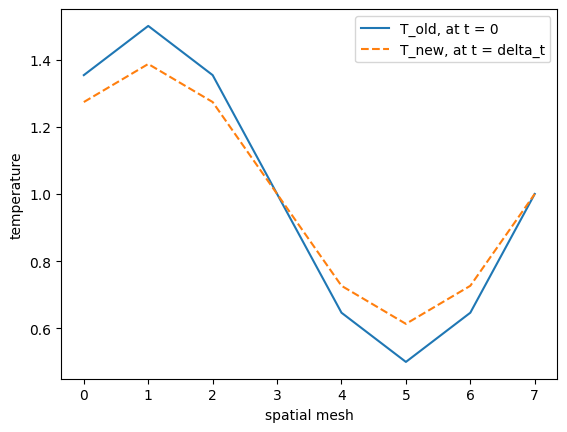

In [3]:
import matplotlib.pyplot as plt
plt.plot(T_old, label='T_old, at t = 0')
plt.plot(T_new, label='T_new, at t = delta_t', linestyle='dashed')
plt.legend()
plt.xlabel('spatial mesh')
plt.ylabel('temperature')
plt.show()

## Preliminaries: direct normalization (by classical solution)

In [4]:
# T_old
TT_old = np.sum(T_old**2)
b0 = np.sqrt(TT_old)
print(b0)
b = T_old/b0

# T_new
TT_new = np.sum(T_new**2)
x0 = np.sqrt(TT_new)
x_th = T_new/x0 # (theoretical)

# Linear system (normalized)
f = np.sqrt(TT_new/TT_old) 
A = C*f # (normalized)

3.0


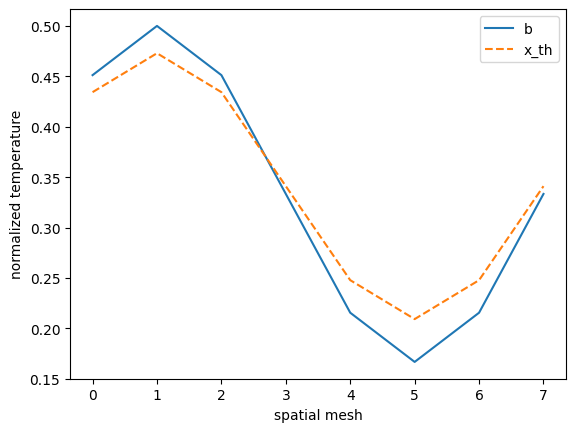

In [5]:
plt.plot(b, label='b')
plt.plot(x_th, label='x_th', linestyle='dashed')
plt.legend()
plt.xlabel('spatial mesh')
plt.ylabel('normalized temperature')
plt.show()

## Quantum observable

In [6]:
# Quantum observable for T_new, or better for |x> (normalized)
# O = A^dag ( I - |b><b| ) A
# <x|O|x> --> 0 (minimum) 
# 
# because A^dag = f C^dag then
# O = f^2 C^dag ( I - |b><b| ) C
# which has the same minimum for |x>
# 
# Ref: PHYSICAL REVIEW A 107, 052422 (2023)
# Depth analysis of variational quantum algorithms for the heat equation

O = np.identity(N)-np.outer(b,b)
O = np.matmul(O,C)
C_dag = np.transpose(C)
O = np.matmul(C_dag,O)

In [7]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Operator

observable = SparsePauliOp.from_operator(O)
print(observable)
print(len(observable.paulis))

SparsePauliOp(['III', 'IIX', 'IXI', 'IXX', 'IXZ', 'IYY', 'IZI', 'IZX', 'IZZ', 'XII', 'XIX', 'XXI', 'XXX', 'XXZ', 'XYY', 'XZI', 'XZX', 'XZZ', 'YIY', 'YXY', 'YYI', 'YYX', 'YYZ', 'YZY', 'ZII', 'ZIX', 'ZIZ', 'ZXI', 'ZXX', 'ZXZ', 'ZYY', 'ZZI', 'ZZX', 'ZZZ'],
              coeffs=[ 4.3656726 +0.j, -2.12752751+0.j,  0.12728074+0.j, -1.12752751+0.j,
 -0.01160814+0.j, -1.0164164 +0.j, -0.01160814+0.j, -0.0164164 +0.j,
  0.01160814+0.j, -0.08789482+0.j, -0.09469472+0.j,  0.15049703+0.j,
 -1.09469472+0.j,  0.01160814+0.j,  1.0164164 -0.j,  0.01160814+0.j,
  0.0164164 +0.j, -0.01160814+0.j,  0.01487594-0.j,  0.01487594-0.j,
  0.0359137 -0.j,  0.0359137 -0.j, -0.0359137 +0.j, -0.0359137 +0.j,
 -0.08670334+0.j, -0.08670334+0.j, -0.01487594+0.j, -0.08670334+0.j,
 -0.08670334+0.j, -0.01487594+0.j, -0.0359137 +0.j, -0.0359137 +0.j,
 -0.0359137 +0.j,  0.0359137 +0.j])
34


In [8]:
from numpy.linalg import eigvalsh
eigenvalues = eigvalsh(O)
print(min(eigenvalues))

-6.657273225306448e-16


## Loss/cost function for VQE

In [9]:
def cost_func_vqe(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (Estimator): Estimator primitive instance

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, hamiltonian, params)
    cost = estimator.run([pub]).result()[0].data.evs

    return cost

## Ansatz

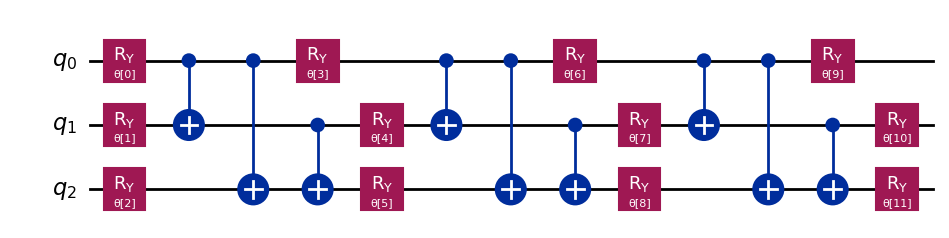

In [10]:
from qiskit.circuit.library import TwoLocal
from qiskit import QuantumCircuit
from qiskit.circuit.library import EfficientSU2

import numpy as np

num_qubits = n

# Best rational ansatz with minimum number of parameters
raw_ansatz = TwoLocal(num_qubits, rotation_blocks="ry", entanglement_blocks="cx", entanglement="full")

raw_ansatz.decompose().draw('mpl')

In [11]:
raw_ansatz.num_parameters

12

## Quantum simulator (qiskit)

In [12]:
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.primitives import StatevectorSampler as Sampler
import numpy as np

estimator = Estimator()
sampler = Sampler()

# Initial (arbitrary) set of parameter
theta0 = np.ones(raw_ansatz.num_parameters)

## Quantum minimization

In [13]:
# SciPy minimizer routine
from scipy.optimize import minimize
import time

# Variational quantum eigensolver (VQE)
# See https://learning.quantum.ibm.com/tutorial/variational-quantum-eigensolver
start_time = time.time()

result = minimize(cost_func_vqe, theta0, args=(raw_ansatz.decompose(), observable, estimator), 
                  method="COBYLA", 
                  tol = 1e-3, # better tolerance is possible but it would require more iterations/time
                  options={'maxiter': 10000, 'disp': True})
print(result)

end_time = time.time()
execution_time = end_time - start_time
print(f"""Time (s): {execution_time}""")

Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 366   Least value of F = 1.1241863724139461e-06
The corresponding X is:
[1.55244487 1.79309036 1.99277067 1.56728144 0.96251285 1.34331082
 2.44686358 0.51786918 0.36780372 1.93602879 0.74234825 0.49130592]

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: 1.1241863724139461e-06
       x: [ 1.552e+00  1.793e+00  1.993e+00  1.567e+00  9.625e-01
            1.343e+00  2.447e+00  5.179e-01  3.678e-01  1.936e+00
            7.423e-01  4.913e-01]
    nfev: 366
   maxcv: 0.0
Time (s): 2.3982250690460205


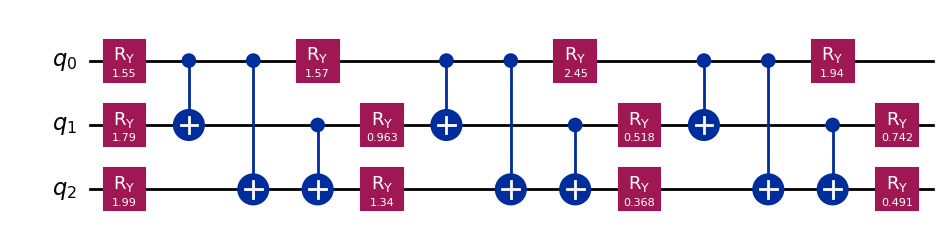

In [14]:
theta = result.x # Final optimized parameters
ansatz = raw_ansatz.assign_parameters(theta)
ansatz.decompose().draw('mpl')

## Simulted quantum results

In [15]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

ideal_distribution = Statevector.from_instruction(ansatz).probabilities_dict()

In [16]:
# Solution (quantum)
y = np.real(list(ideal_distribution.values())) # probabilities
x = np.sqrt(y) # amplitudes

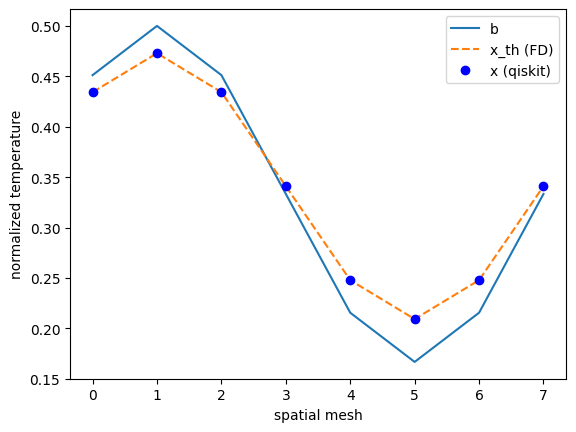

In [17]:
plt.plot(b, label='b')
plt.plot(x_th, label='x_th (FD)', linestyle='dashed')
plt.plot(x, 'bo', label='x (qiskit)')
plt.legend()
plt.xlabel('spatial mesh')
plt.ylabel('normalized temperature')
plt.show()

## De-normalization by post-processing

In [18]:
import statistics

x_mean = statistics.mean(x)
T_mean = statistics.mean(T_old)
scale = T_mean/x_mean
print(f"\nscale = {scale}")

T_new_q = x*scale


scale = 2.931954897779956


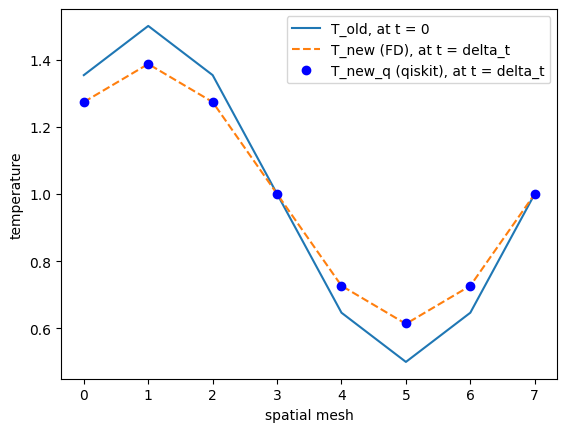

In [19]:
plt.plot(T_old, label='T_old, at t = 0')
plt.plot(T_new, label='T_new (FD), at t = delta_t', linestyle='dashed')
plt.plot(T_new_q, 'bo', label='T_new_q (qiskit), at t = delta_t')
plt.legend()
plt.xlabel('spatial mesh')
plt.ylabel('temperature')
plt.show()

## Simulated quantum results (qrisp with statistics)

In [20]:
from qrisp import *
from qrisp.operators import QubitOperator
from qrisp.operators.qubit import X,Y,Z
from qrisp.vqe.vqe_problem import *

# Hamiltonian
H = QubitOperator.from_matrix(O).to_pauli()

# Ansatz
def ansatz(qv,theta):
    for i in range(num_qubits):
        ry(theta[i],qv[i])
    for i in range(num_qubits-1):
        cx(qv[i],qv[i+1])
    cx(qv[2],qv[0])

vqe = VQEProblem(hamiltonian = H,
                 ansatz_function = ansatz,
                 num_params = 3,
                 callback = True)

repetitions = 30

all_results = np.empty(repetitions, dtype = object)

for k in range(repetitions):
    print(f"repetition: {k}")    
    
    qarg = QuantumVariable(num_qubits, name="q")
    optimal_function = vqe.train_function(qarg,
            depth = 4,
            max_iter = 1000000000,
            mes_kwargs={'precision': 0.0005,'diagonalisation_method':'commuting'},
            optimizer = 'COBYQA', # Available are, e.g., COBYLA, COBYQA, Nelder-Mead
            init_type = 'random', 
            options = {'tol': 0.0001, 'disp': True} # RUN ON SIMULATOR
        )
    optimal_ansatz = QuantumVariable(num_qubits, name="q")
    optimal_function(optimal_ansatz)
    all_results[k] = optimal_ansatz.get_measurement(shots = 4000000)
    qarg.delete()
    
qarg = optimal_ansatz

c:\Users\p.asinari\Qiskit\envs\thermal-science2\Lib\site-packages\qrisp\algorithms\vqe\vqe_problem.py:398: OptimizeWarning: Unknown solver options: tol
  res_sample = minimize(


repetition: 0
Starting the optimization procedure.
Initial trust-region radius: 1.0.
Final trust-region radius: 1e-06.
Maximum number of function evaluations: 6000.
Maximum number of iterations: 1000000000.

optimization_wrapper([ 1.133e+00  1.023e+00 ...  3.347e-01  3.473e-01]) = 2.9623438408442664
optimization_wrapper([ 2.133e+00  1.023e+00 ...  3.347e-01  3.473e-01]) = 5.529128687929199
optimization_wrapper([ 1.133e+00  2.023e+00 ...  3.347e-01  3.473e-01]) = 4.873060518351587
optimization_wrapper([ 1.133e+00  1.023e+00 ...  3.347e-01  3.473e-01]) = 3.2980348517902733
optimization_wrapper([ 1.133e+00  1.023e+00 ...  3.347e-01  3.473e-01]) = 4.830546491973607
optimization_wrapper([ 1.133e+00  1.023e+00 ...  3.347e-01  3.473e-01]) = 3.778240236824549
optimization_wrapper([ 1.133e+00  1.023e+00 ...  3.347e-01  3.473e-01]) = 3.6471325044862986
optimization_wrapper([ 1.133e+00  1.023e+00 ...  3.347e-01  3.473e-01]) = 3.3321500172741647
optimization_wrapper([ 1.133e+00  1.023e+00 ...  3.3

c:\Users\p.asinari\Qiskit\envs\thermal-science2\Lib\site-packages\qrisp\algorithms\vqe\vqe_problem.py:398: OptimizeWarning: Unknown solver options: tol
  res_sample = minimize(


repetition: 1
Starting the optimization procedure.
Initial trust-region radius: 1.0.
Final trust-region radius: 1e-06.
Maximum number of function evaluations: 6000.
Maximum number of iterations: 1000000000.

optimization_wrapper([ 1.198e+00  6.013e-01 ...  9.173e-01  1.011e+00]) = 4.654775655911754
optimization_wrapper([ 2.198e+00  6.013e-01 ...  9.173e-01  1.011e+00]) = 6.370408533425604
optimization_wrapper([ 1.198e+00  1.601e+00 ...  9.173e-01  1.011e+00]) = 4.929656371428988
optimization_wrapper([ 1.198e+00  6.013e-01 ...  9.173e-01  1.011e+00]) = 5.8589511865904855
optimization_wrapper([ 1.198e+00  6.013e-01 ...  9.173e-01  1.011e+00]) = 5.07437069773432
optimization_wrapper([ 1.198e+00  6.013e-01 ...  9.173e-01  1.011e+00]) = 4.4735435045947956
optimization_wrapper([ 1.198e+00  6.013e-01 ...  9.173e-01  1.011e+00]) = 4.525341907309595
optimization_wrapper([ 1.198e+00  6.013e-01 ...  9.173e-01  1.011e+00]) = 4.678724917974001
optimization_wrapper([ 1.198e+00  6.013e-01 ...  9.173e

c:\Users\p.asinari\Qiskit\envs\thermal-science2\Lib\site-packages\qrisp\algorithms\vqe\vqe_problem.py:398: OptimizeWarning: Unknown solver options: tol
  res_sample = minimize(


...

repetition: 27
Starting the optimization procedure.
Initial trust-region radius: 1.0.
Final trust-region radius: 1e-06.
Maximum number of function evaluations: 6000.
Maximum number of iterations: 1000000000.

optimization_wrapper([ 3.637e-01  1.454e+00 ...  6.524e-01  8.970e-01]) = 4.040666934502554
optimization_wrapper([ 1.364e+00  1.454e+00 ...  6.524e-01  8.970e-01]) = 5.730819495218896
optimization_wrapper([ 3.637e-01  2.454e+00 ...  6.524e-01  8.970e-01]) = 5.4308053133274345
optimization_wrapper([ 3.637e-01  1.454e+00 ...  6.524e-01  8.970e-01]) = 3.9905912775316708
optimization_wrapper([ 3.637e-01  1.454e+00 ...  6.524e-01  8.970e-01]) = 4.244170131439118
optimization_wrapper([ 3.637e-01  1.454e+00 ...  6.524e-01  8.970e-01]) = 5.113654201206174
optimization_wrapper([ 3.637e-01  1.454e+00 ...  6.524e-01  8.970e-01]) = 2.921942466167495
optimization_wrapper([ 3.637e-01  1.454e+00 ...  6.524e-01  8.970e-01]) = 2.961936956360995
optimization_wrapper([ 3.637e-01  1.454e+00 ...  6.52

c:\Users\p.asinari\Qiskit\envs\thermal-science2\Lib\site-packages\qrisp\algorithms\vqe\vqe_problem.py:398: OptimizeWarning: Unknown solver options: tol
  res_sample = minimize(


repetition: 28
Starting the optimization procedure.
Initial trust-region radius: 1.0.
Final trust-region radius: 1e-06.
Maximum number of function evaluations: 6000.
Maximum number of iterations: 1000000000.

optimization_wrapper([ 5.366e-03  1.027e+00 ...  1.448e+00  6.020e-02]) = 4.099981655507155
optimization_wrapper([ 1.005e+00  1.027e+00 ...  1.448e+00  6.020e-02]) = 3.6892843976112415
optimization_wrapper([ 5.366e-03  2.027e+00 ...  1.448e+00  6.020e-02]) = 3.8515996441138234
optimization_wrapper([ 5.366e-03  1.027e+00 ...  1.448e+00  6.020e-02]) = 3.9721336437936565
optimization_wrapper([ 5.366e-03  1.027e+00 ...  1.448e+00  6.020e-02]) = 5.606542265600497
optimization_wrapper([ 5.366e-03  1.027e+00 ...  1.448e+00  6.020e-02]) = 4.341761622474985
optimization_wrapper([ 5.366e-03  1.027e+00 ...  1.448e+00  6.020e-02]) = 3.0948142889833106
optimization_wrapper([ 5.366e-03  1.027e+00 ...  1.448e+00  6.020e-02]) = 4.963166137854568
optimization_wrapper([ 5.366e-03  1.027e+00 ...  1.

c:\Users\p.asinari\Qiskit\envs\thermal-science2\Lib\site-packages\qrisp\algorithms\vqe\vqe_problem.py:398: OptimizeWarning: Unknown solver options: tol
  res_sample = minimize(


repetition: 29
Starting the optimization procedure.
Initial trust-region radius: 1.0.
Final trust-region radius: 1e-06.
Maximum number of function evaluations: 6000.
Maximum number of iterations: 1000000000.

optimization_wrapper([ 1.287e+00  5.569e-01 ...  8.798e-01  1.363e+00]) = 3.6007100490350896
optimization_wrapper([ 2.287e+00  5.569e-01 ...  8.798e-01  1.363e+00]) = 4.677939491446893
optimization_wrapper([ 1.287e+00  1.557e+00 ...  8.798e-01  1.363e+00]) = 4.280381964744533
optimization_wrapper([ 1.287e+00  5.569e-01 ...  8.798e-01  1.363e+00]) = 5.2243822948981204
optimization_wrapper([ 1.287e+00  5.569e-01 ...  8.798e-01  1.363e+00]) = 3.3652276854438385
optimization_wrapper([ 1.287e+00  5.569e-01 ...  8.798e-01  1.363e+00]) = 3.002234945500165
optimization_wrapper([ 1.287e+00  5.569e-01 ...  8.798e-01  1.363e+00]) = 5.010876934639359
optimization_wrapper([ 1.287e+00  5.569e-01 ...  8.798e-01  1.363e+00]) = 4.77576466729899
optimization_wrapper([ 1.287e+00  5.569e-01 ...  8.79

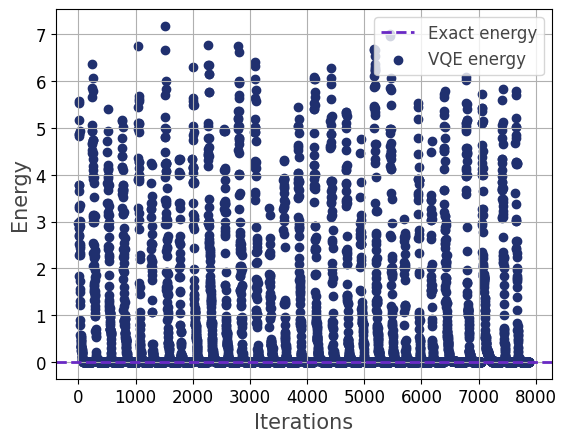

In [21]:
vqe.visualize_energy(exact=True)

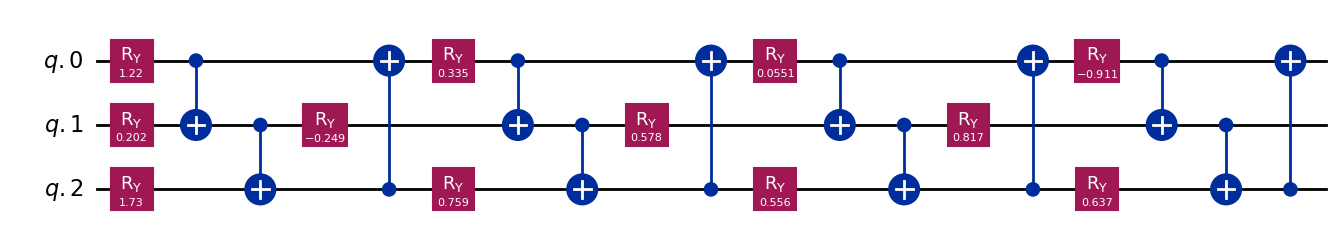

In [22]:
qiskit_qarg = qarg.qs.compile().to_qiskit()
qiskit_qarg.draw("mpl")

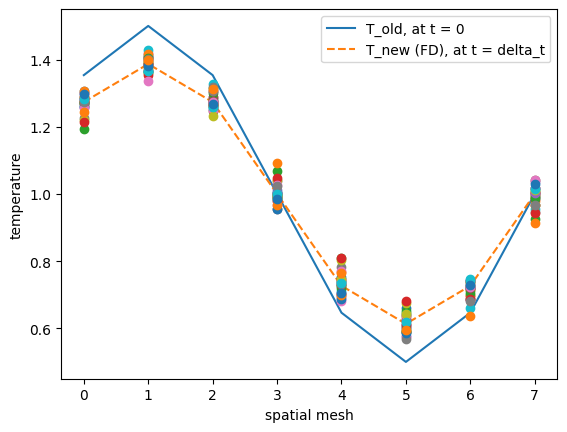

In [ ]:
import matplotlib.pyplot as plt

plt.plot(T_old, label='T_old, at t = 0')
plt.plot(T_new, label='T_new (FD), at t = delta_t', linestyle='dashed')
plt.legend()
plt.xlabel('spatial mesh')
plt.ylabel('temperature')

all_values = []
#for k in range(until_repetitions):
for k in range(repetitions):
    results = all_results[k]
    # Estrai chiavi e valori
    keys = results.keys()
    values = results.values()

    # Ordina le chiavi in ordine binario crescente
    sorted_keys = sorted(results.keys())

    # Estrai i valori nell'ordine corretto
    sorted_values = [results[k] for k in sorted_keys]

    # Solution (quantum)
    y = np.real(list(sorted_values)) # probabilities
    x = np.sqrt(y) # amplitudes
    T_new_qrisp = x*scale

    if T_new_qrisp.shape == (N,):
        all_values.append(T_new_qrisp)

    plt.plot(T_new_qrisp, 'o', label='T_new_q (qrisp), at t = delta_t')

plt.show()

(29, 8)


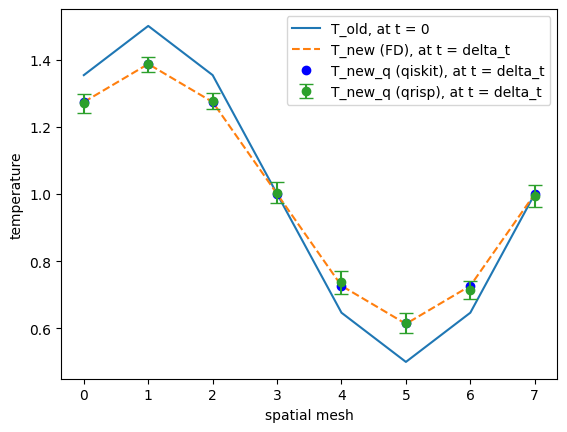

In [ ]:
plt.plot(T_old, label='T_old, at t = 0')
plt.plot(T_new, label='T_new (FD), at t = delta_t', linestyle='dashed')
plt.plot(T_new_q, 'bo', label='T_new_q (qiskit), at t = delta_t')
plt.xlabel('spatial mesh')
plt.ylabel('temperature')

# Transform list to 2D array: (30,8)
new_all_values = np.array(new_all_values)
print(new_all_values.shape)

mean_T = np.mean(new_all_values, axis=0)      # mean
error_bar_T = np.std(new_all_values, axis=0)  # standard deviation

# Plot with with error bars
plt.errorbar(range(len(mean_T)), mean_T, yerr = error_bar_T, fmt='o', capsize=5, label='T_new_q (qrisp), at t = delta_t')
#plt.grid(True)
plt.legend()
plt.show()
